

24ADI204-DATA SCIENCE AND VISUALISATON

 TEAM-16

 WEEK 2 (EDA)



OBJECTIVE:

To explore and understand the Chicago Crime dataset by examining its structure, variables, data types, missing values, duplicates, and statistical characteristics, while identifying important crime patterns and relationships. The analysis prepares the dataset for effective visualization, interpretation, and further exploratory data analysis.


Importing The Libraries:

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [ ]:
import os

files = os.listdir('/content')

for file in files:
    if file.endswith('.csv'):
        print(file)

Chicago_Crimes_2001_to_Present.csv


In [61]:
import pandas as pd

df = pd.read_csv(
    '/content/Chicago_Crimes_2001_to_Present.csv',
    engine='python',
    on_bad_lines='skip',
    encoding='utf-8',
    encoding_errors='ignore'
)

print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

Dataset loaded successfully!
Rows and Columns: (948068, 22)


UNDERSTANDING THE DATASET:

In [58]:


print("=" * 60)
print("1. DATASET DIMENSIONS")
print("=" * 60)
print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])


print("\n" + "=" * 60)
print("2. COLUMN NAMES")
print("=" * 60)
print(df.columns.tolist())


print("\n" + "=" * 60)
print("3. DATA TYPES")
print("=" * 60)
print(df.dtypes)


print("\n" + "=" * 60)
print("4. MISSING / NULL VALUES")
print("=" * 60)
null_values = df.isnull().sum()
print(null_values[null_values > 0])


print("\n" + "=" * 60)
print("5. DUPLICATE RECORDS")
print("=" * 60)
print("Number of duplicate rows :", df.duplicated().sum())


print("\n" + "=" * 60)
print("6. UNIQUE VALUES")
print("=" * 60)
print("Unique Crime Types       :", df['Primary Type'].nunique())
print("Unique Crime Descriptions:", df['Description'].nunique())
print("Unique Locations         :", df['Location Description'].nunique())
print("Unique Districts         :", df['District'].nunique())






1. DATASET DIMENSIONS
Number of Rows    : 392420
Number of Columns : 26

2. COLUMN NAMES
['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location', 'Month', 'Day', 'Hour', 'Day_of_Week']

3. DATA TYPES
ID                               int64
Case Number                     object
Date                    datetime64[ns]
Block                           object
IUCR                            object
Primary Type                    object
Description                     object
Location Description            object
Arrest                          object
Domestic                        object
Beat                           float64
District                       float64
Ward                           float64
Community Area                 float64
FBI Code                        object

In [67]:
# Preparing date and time features for visualization

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Hour'] = df['Date'].dt.hour
df['Day_of_Week'] = df['Date'].dt.day_name()

print("Date and time features created successfully!")

Date and time features created successfully!


Graph 1:Crime Incident Distribution by Hour

This histogram shows how crime incidents are distributed across different hours of the day, highlighting periods of higher and lower crime activity.

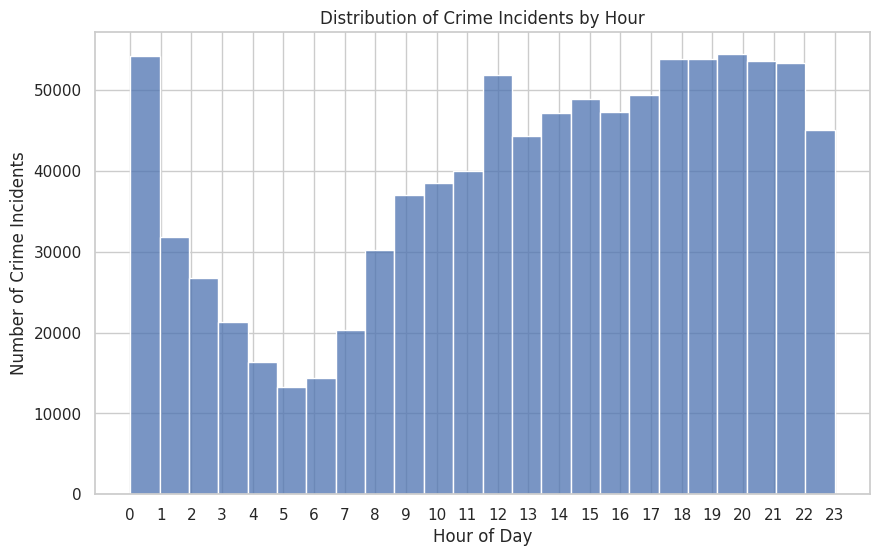

In [68]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Hour'].dropna(),
    bins=24,
    kde=False
)

plt.title('Distribution of Crime Incidents by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Crime Incidents')
plt.xticks(range(24))
plt.show()

Graph 2: KDE Plot - Crime Distribution by Hour

The KDE plot provides a smooth view of crime activity across different hours. Peaks represent periods when crime incidents are more concentrated.

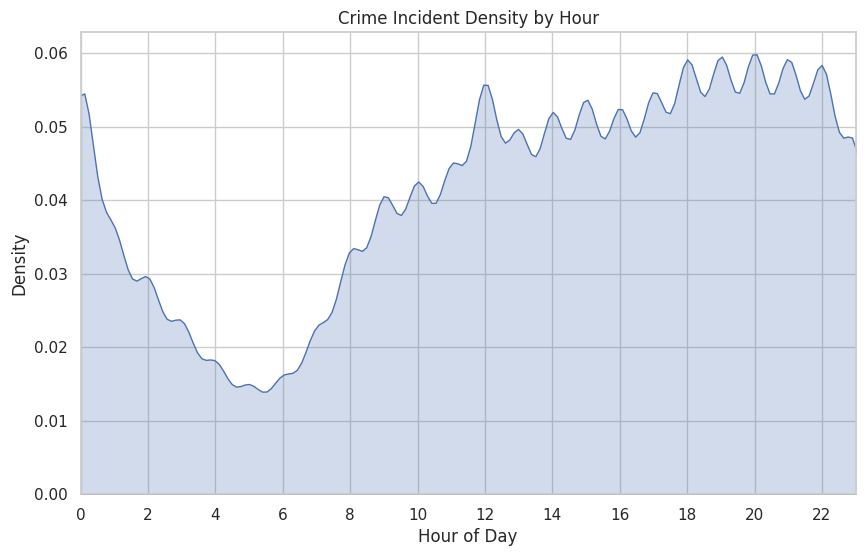

In [69]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='Hour',
    fill=True
)

plt.title('Crime Incident Density by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Density')
plt.xlim(0, 23)
plt.xticks(range(0, 24, 2))

plt.show()

Graph 3: Box Plot - Annual Crime Count Variation


The box plot summarizes the variation in the number of reported crimes across different years and helps identify unusually high or low annual totals.

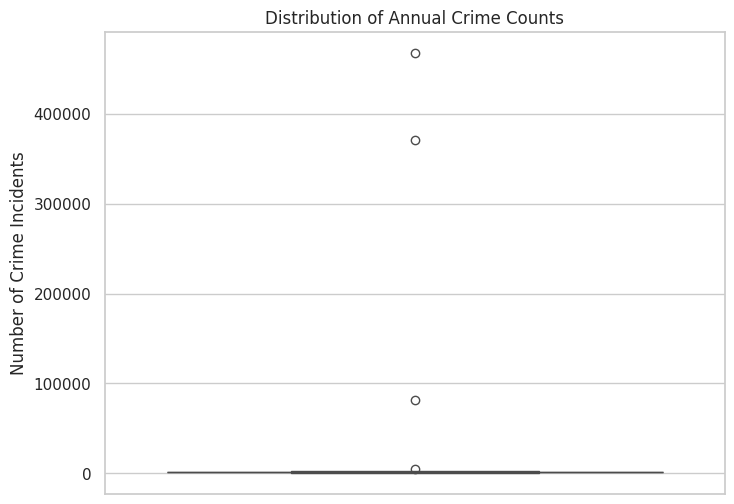

In [70]:

yearly_counts = df.groupby('Year').size()

plt.figure(figsize=(8, 6))

sns.boxplot(
    y=yearly_counts.values
)

plt.title('Distribution of Annual Crime Counts')
plt.ylabel('Number of Crime Incidents')

plt.show()

Graph 4: Violin Plot - Crime Hours by Day of Week

This visualization shows how the timing of reported crimes varies across different days of the week.

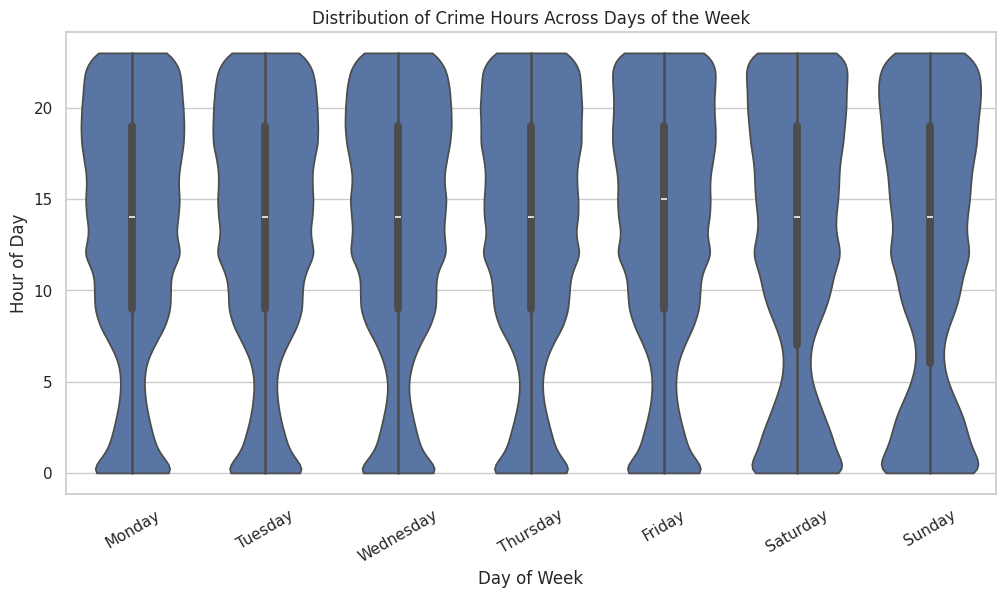

In [71]:


day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='Day_of_Week',
    y='Hour',
    order=day_order,
    cut=0
)

plt.title('Distribution of Crime Hours Across Days of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')

plt.xticks(rotation=30)

plt.show()

Graph 5: Pie Chart - Arrest Status

The pie chart shows the proportion of reported crime incidents that resulted in an arrest compared with those that did not.

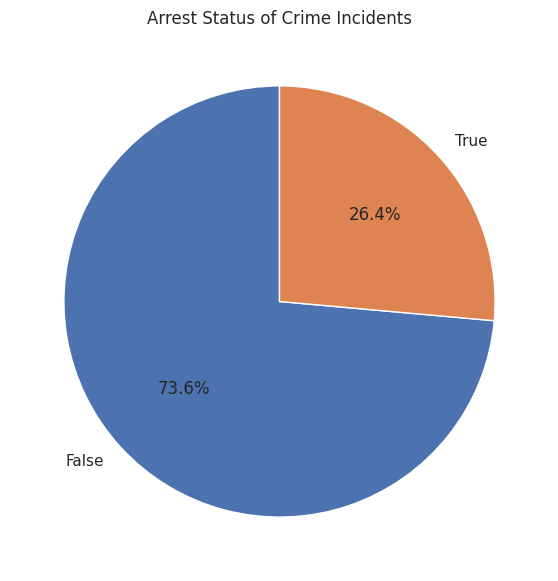

In [17]:


arrest_counts = df['Arrest'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    arrest_counts.values,
    labels=arrest_counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Arrest Status of Crime Incidents')

plt.show()

Graph 6: Donut Chart - Domestic Crime

The donut chart displays the proportion of incidents classified as domestic and non-domestic.

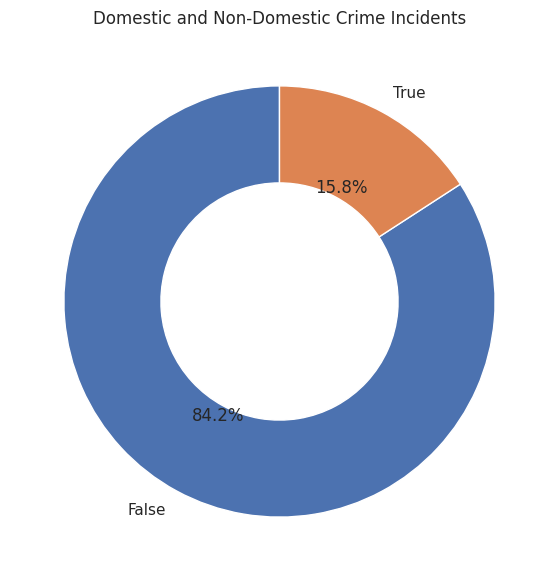

In [18]:


domestic_counts = df['Domestic'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    domestic_counts.values,
    labels=domestic_counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.45}
)

plt.title('Domestic and Non-Domestic Crime Incidents')

plt.show()

Graph 7: Line Chart - Yearly Crime Trend

The line chart shows how the number of reported crime incidents has changed over the years.

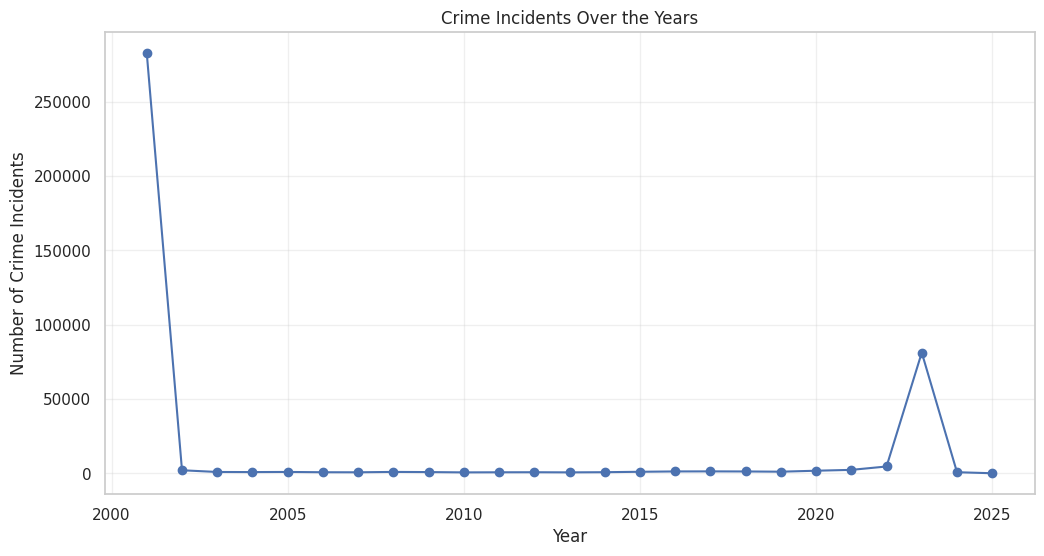

In [19]:


yearly_crimes = df.groupby('Year').size().sort_index()

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_crimes.index,
    yearly_crimes.values,
    marker='o'
)

plt.title('Crime Incidents Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Crime Incidents')

plt.grid(True, alpha=0.3)

plt.show()

 Graph 8: Area Chart - Monthly Crime Pattern

The area chart highlights how crime activity changes throughout the calendar year and helps identify months with higher or lower incident volumes.

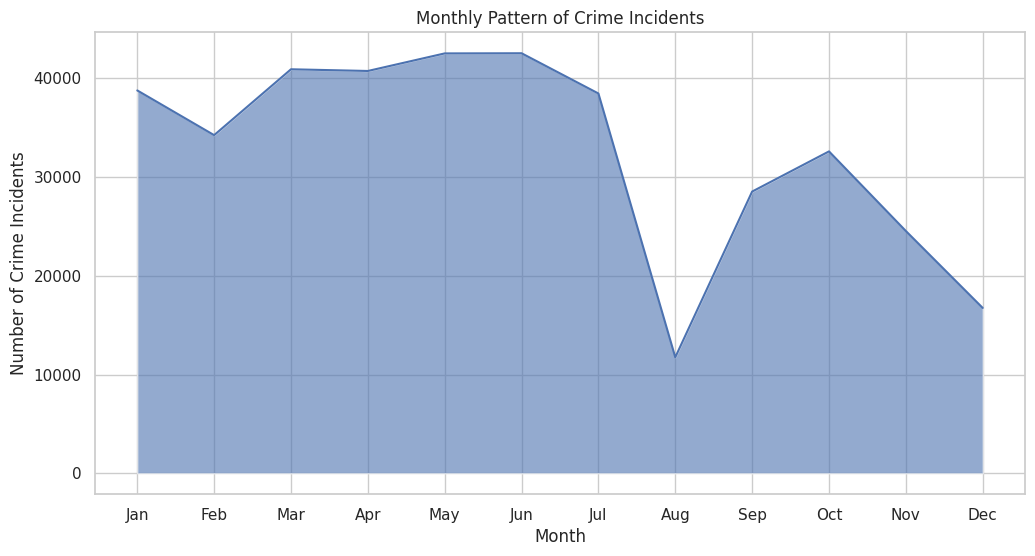

In [20]:


monthly_crimes = (
    df.groupby('Month')
      .size()
      .reindex(range(1, 13), fill_value=0)
)

month_names = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

plt.figure(figsize=(12, 6))

plt.fill_between(
    range(1, 13),
    monthly_crimes.values,
    alpha=0.6
)

plt.plot(
    range(1, 13),
    monthly_crimes.values
)

plt.title('Monthly Pattern of Crime Incidents')
plt.xlabel('Month')
plt.ylabel('Number of Crime Incidents')

plt.xticks(range(1, 13), month_names)

plt.show()

Graph 9: Heatmap - Day and Hour Crime Pattern

The heatmap identifies combinations of days and hours where crime incidents are more concentrated.

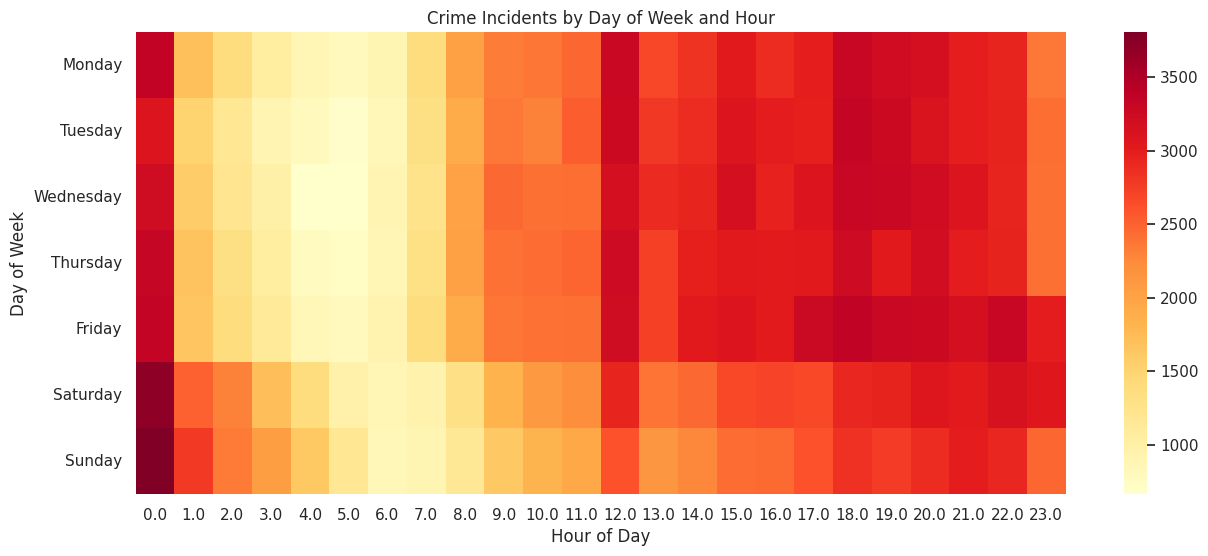

In [21]:


day_hour = pd.crosstab(
    df['Day_of_Week'],
    df['Hour']
).reindex(day_order)

plt.figure(figsize=(15, 6))

sns.heatmap(
    day_hour,
    cmap='YlOrRd'
)

plt.title('Crime Incidents by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.show()

 Graph 10: Lollipop Chart - Top Crime Locations

The lollipop chart ranks the ten locations most frequently associated with reported crime incidents.

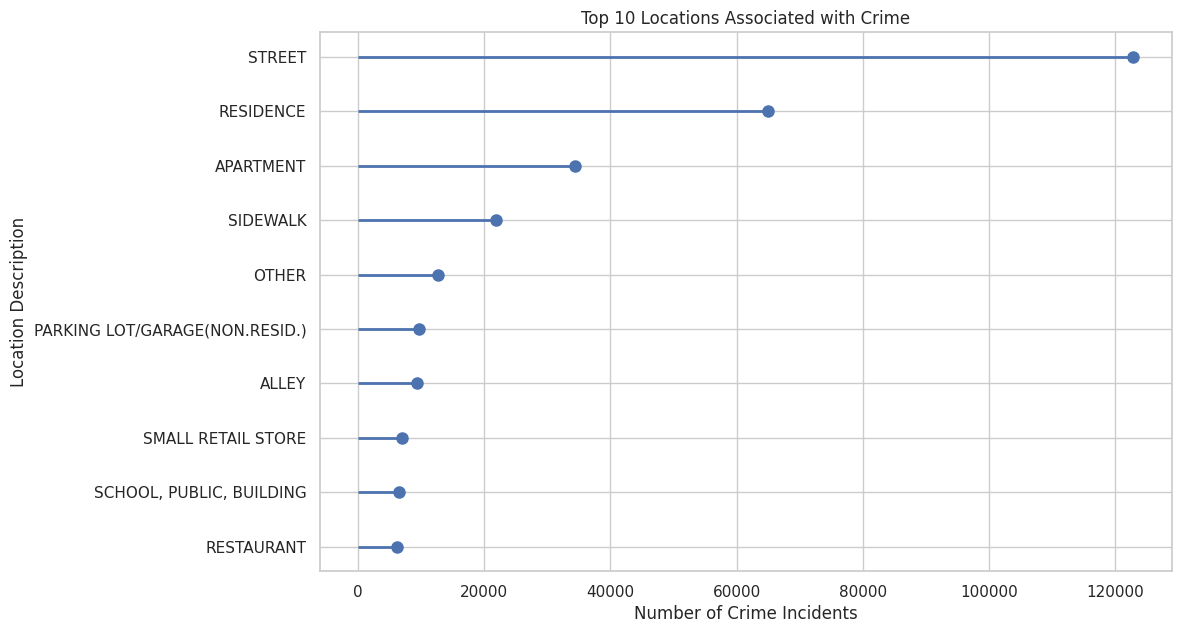

In [22]:

location_counts = (
    df['Location Description']
    .dropna()
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(11, 7))

plt.hlines(
    y=location_counts.index,
    xmin=0,
    xmax=location_counts.values,
    linewidth=2
)

plt.plot(
    location_counts.values,
    location_counts.index,
    'o',
    markersize=8
)

plt.title('Top 10 Locations Associated with Crime')
plt.xlabel('Number of Crime Incidents')
plt.ylabel('Location Description')

plt.show()

Graph 11: Geographic Scatter Plot

Each point represents a reported crime location. Concentrated groups of points indicate areas with greater spatial crime activity.

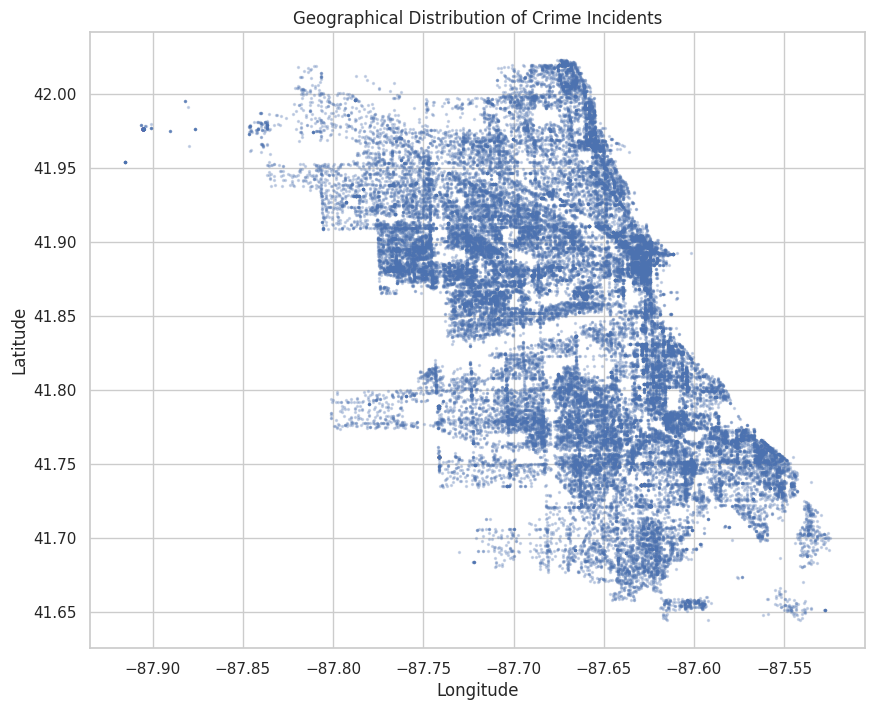

In [24]:


geo = df[['Longitude', 'Latitude']].copy()

geo['Longitude'] = pd.to_numeric(geo['Longitude'], errors='coerce')
geo['Latitude'] = pd.to_numeric(geo['Latitude'], errors='coerce')

geo = geo.dropna()

geo = geo[
    geo['Longitude'].between(-88, -87) &
    geo['Latitude'].between(41, 43)
]

geo_sample = geo.sample(
    min(50000, len(geo)),
    random_state=42
)

plt.figure(figsize=(10, 8))

plt.scatter(
    geo_sample['Longitude'],
    geo_sample['Latitude'],
    s=2,
    alpha=0.25
)

plt.title('Geographical Distribution of Crime Incidents')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

 Graph 12: Geographic Hexbin Density

Each hexagonal region represents an area, and darker/higher-valued regions indicate greater concentrations of crime incidents.**bold text**

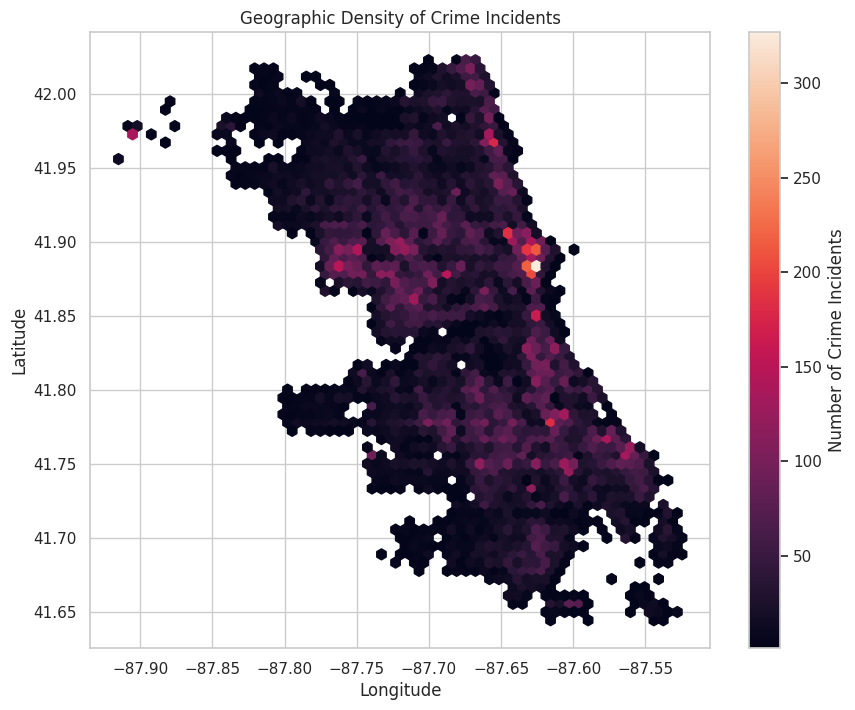

In [25]:


plt.figure(figsize=(10, 8))

plt.hexbin(
    geo_sample['Longitude'],
    geo_sample['Latitude'],
    gridsize=60,
    mincnt=1
)

plt.colorbar(label='Number of Crime Incidents')

plt.title('Geographic Density of Crime Incidents')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

Graph 13: Polar Chart - Crime by Hour

The radial pattern highlights the hours with comparatively high and low crime activity.

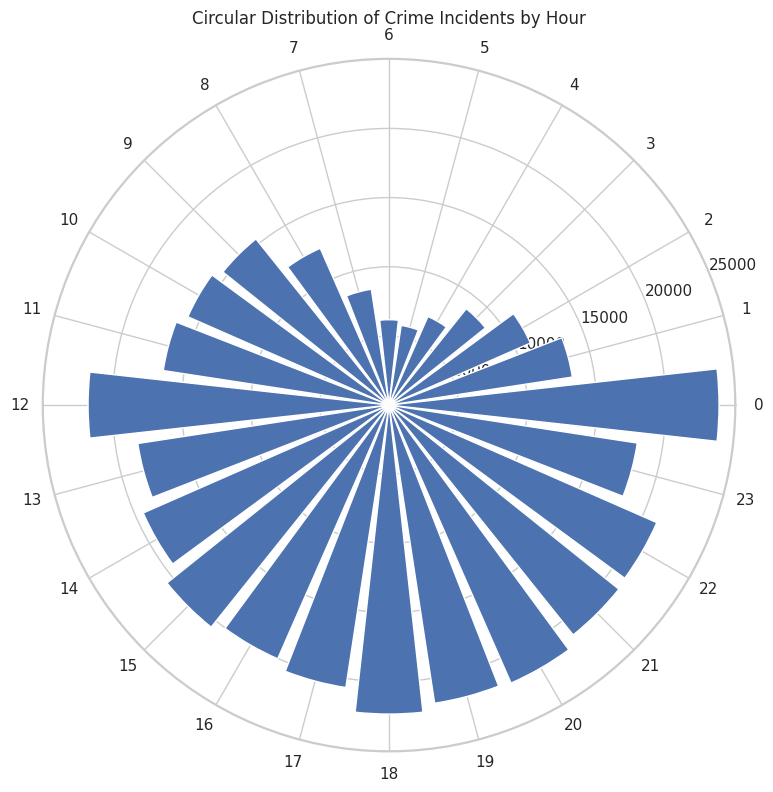

In [28]:


hour_counts = (
    df['Hour']
    .value_counts()
    .reindex(range(24), fill_value=0)
)

angles = np.linspace(
    0,
    2 * np.pi,
    24,
    endpoint=False
)

fig = plt.figure(figsize=(9, 9))

ax = fig.add_subplot(111, polar=True)

ax.bar(
    angles,
    hour_counts.values,
    width=0.22
)

ax.set_xticks(angles)
ax.set_xticklabels(range(24))

ax.set_title(
    'Circular Distribution of Crime Incidents by Hour',
    pad=25
)

plt.show()

 Graph 14: Stem Plot - Hourly Crime Counts

 The stems make the rise and fall of crime frequency across individual hours easy to compare

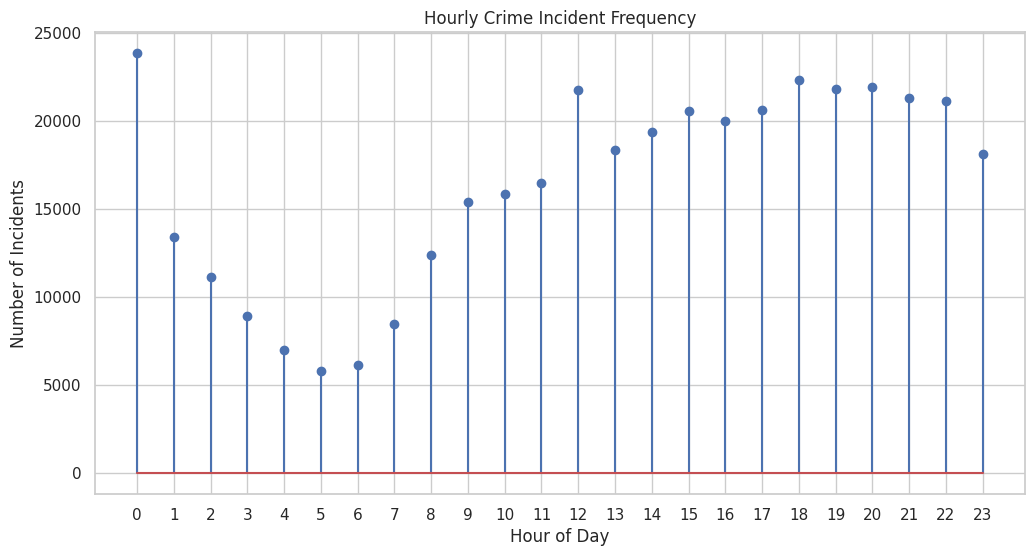

In [29]:


hour_counts = (
    df['Hour']
    .value_counts()
    .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(12, 6))

plt.stem(
    range(24),
    hour_counts.values
)

plt.title('Hourly Crime Incident Frequency')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Incidents')
plt.xticks(range(24))

plt.show()

 Graph 15: ECDF of Annual Crime Counts

The ECDF indicates what proportion of years had crime totals below each crime-count value.

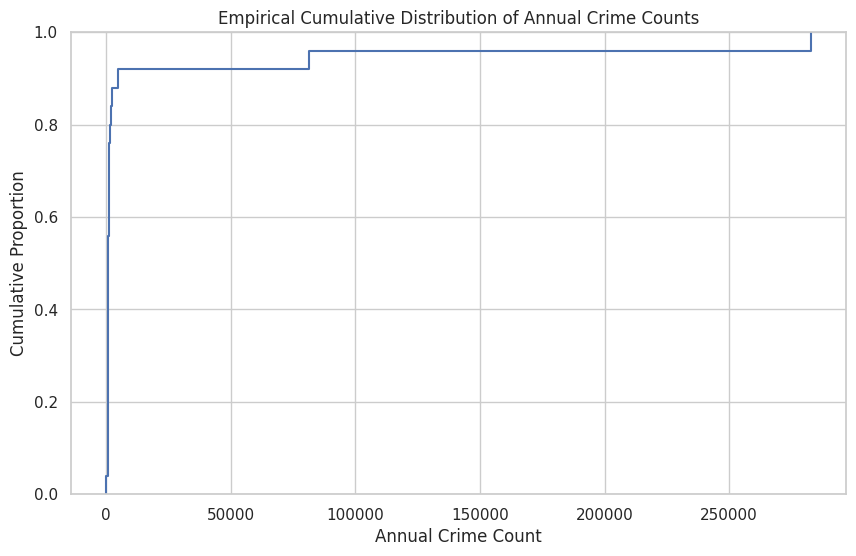

In [30]:


annual_counts = (
    df.groupby('Year')
      .size()
      .sort_values()
)

plt.figure(figsize=(10, 6))

sns.ecdfplot(
    x=annual_counts.values
)

plt.title('Empirical Cumulative Distribution of Annual Crime Counts')
plt.xlabel('Annual Crime Count')
plt.ylabel('Cumulative Proportion')

plt.show()

Graph 16: Rug Plot - Crime Hours

Each small mark represents an observation, making concentrations of reported crime hours visible.

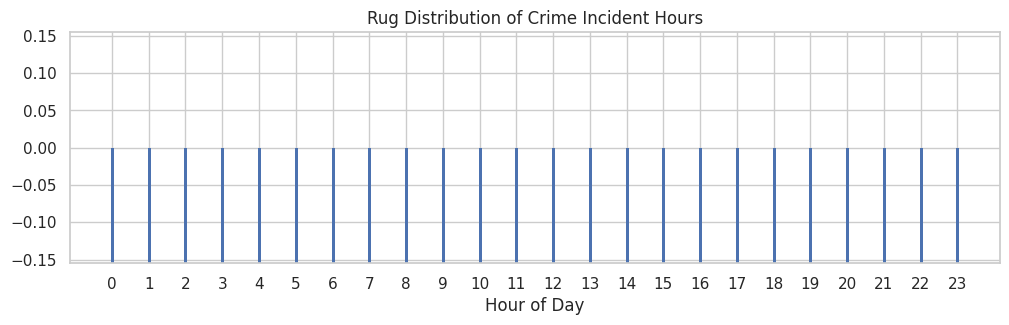

In [32]:


hour_sample = df['Hour'].dropna()

hour_sample = hour_sample.sample(
    min(5000, len(hour_sample)),
    random_state=42
)

plt.figure(figsize=(12, 3))

sns.rugplot(
    x=hour_sample,
    height=0.5
)

plt.title('Rug Distribution of Crime Incident Hours')
plt.xlabel('Hour of Day')

plt.xticks(range(24))

plt.show()

Graph 17: Mosaic Plot - Arrest vs Domestic

The area of each rectangle represents the frequency of a particular Arrest–Domestic combination.

<Figure size 900x600 with 0 Axes>

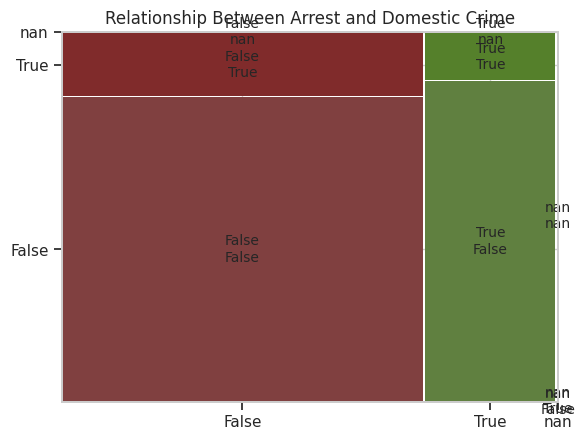

In [34]:


# Graph 17: Mosaic Plot - Arrest vs Domestic Crime

from statsmodels.graphics.mosaicplot import mosaic

mosaic_data = pd.crosstab(
    df['Arrest'].astype(str),
    df['Domestic'].astype(str)
)

plt.figure(figsize=(9, 6))

mosaic(
    mosaic_data.stack().to_dict(),
    title='Relationship Between Arrest and Domestic Crime'
)

plt.show()

Graph 18: Bubble Chart - Crime Type Characteristics

Bubble position represents crime volume and arrest rate, while bubble size represents the domestic-crime proportion.

In [40]:
# Graph 18: Bubble Chart
# Crime Frequency vs Arrest Rate vs Domestic Rate

import plotly.express as px

# Convert Arrest and Domestic into clean numerical values
arrest_clean = (
    df['Arrest']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'true': 1,
        'false': 0
    })
)

domestic_clean = (
    df['Domestic']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'true': 1,
        'false': 0
    })
)

# Create a temporary dataframe for this graph
bubble_df = pd.DataFrame({
    'Primary Type': df['Primary Type'],
    'Arrest': arrest_clean,
    'Domestic': domestic_clean
})

# Remove incomplete records
bubble_df = bubble_df.dropna(
    subset=['Primary Type', 'Arrest', 'Domestic']
)

# Calculate statistics for each crime type
crime_stats = (
    bubble_df
    .groupby('Primary Type')
    .agg(
        Crime_Count=('Primary Type', 'size'),
        Arrest_Rate=('Arrest', 'mean'),
        Domestic_Rate=('Domestic', 'mean')
    )
    .reset_index()
)

# Keep crime types with enough records
crime_stats = crime_stats[
    crime_stats['Crime_Count'] >= 100
].copy()

# Convert rates to percentages
crime_stats['Arrest_Rate'] = (
    crime_stats['Arrest_Rate'] * 100
)

crime_stats['Domestic_Rate'] = (
    crime_stats['Domestic_Rate'] * 100
)

# Create bubble chart
fig = px.scatter(
    crime_stats,
    x='Crime_Count',
    y='Arrest_Rate',
    size='Domestic_Rate',
    hover_name='Primary Type',
    title='Crime Frequency, Arrest Rate and Domestic Rate',
    labels={
        'Crime_Count': 'Number of Crime Incidents',
        'Arrest_Rate': 'Arrest Rate (%)',
        'Domestic_Rate': 'Domestic Rate (%)'
    }
)

fig.show()

Graph 19: Treemap

 Crime Type and Crime Description Hierarchy

The treemap visualizes the hierarchical distribution of crime incidents. The larger sections represent crime types or descriptions with a higher number of reported incidents. This helps identify the most frequently occurring categories and their corresponding crime descriptions.

In [41]:
# Graph 19: Treemap
# Crime Type and Crime Description Hierarchy

import plotly.express as px

# Select only the required columns
treemap_df = df[['Primary Type', 'Description']].copy()

# Remove missing values
treemap_df = treemap_df.dropna(
    subset=['Primary Type', 'Description']
)

# Count each crime type and description combination
treemap_counts = (
    treemap_df
    .groupby(['Primary Type', 'Description'])
    .size()
    .reset_index(name='Crime_Count')
)

# Keep the most frequent 100 combinations
# This makes the visualization readable
treemap_counts = treemap_counts.nlargest(
    100,
    'Crime_Count'
)

# Create the treemap
fig = px.treemap(
    treemap_counts,
    path=['Primary Type', 'Description'],
    values='Crime_Count',
    title='Hierarchy of Crime Types and Descriptions'
)

fig.show()

Graph 20: Funnel Chart

Ranking of the Most Common Crime Types

The funnel chart ranks the ten most frequently reported crime types according to the number of incidents. The widest section represents the crime type with the highest number of incidents, while the sections become narrower as the frequency decreases. This makes it easy to compare the relative prevalence of major crime categories.

In [42]:
# Graph 20: Funnel Chart
# Ranking of the Most Common Crime Types

import plotly.graph_objects as go

# Count crime incidents by Primary Type
funnel_data = (
    df['Primary Type']
    .dropna()
    .value_counts()
    .head(10)
)

# Create funnel chart
fig = go.Figure(
    go.Funnel(
        y=funnel_data.index.tolist(),
        x=funnel_data.values.tolist(),
        textinfo='value+percent initial'
    )
)

fig.update_layout(
    title='Top 10 Crime Types by Number of Incidents',
    height=600
)

fig.show()

Graph 21: Sankey Diagram

Crime Type → Arrest Outcome

The Sankey diagram illustrates the flow between the major crime types and their corresponding arrest outcomes. The width of each flow represents the number of incidents. This visualization helps identify which major crime categories are more frequently associated with arrests or no arrests.

In [44]:
# Graph 21: Sankey Diagram
# Crime Type → Arrest Outcome

import plotly.graph_objects as go

# Clean the Arrest column
arrest_clean = (
    df['Arrest']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'true': 'Arrest',
        'false': 'No Arrest'
    })
)

# Create temporary dataframe
sankey_df = pd.DataFrame({
    'Primary Type': df['Primary Type'],
    'Arrest_Status': arrest_clean
})

# Remove missing values
sankey_df = sankey_df.dropna(
    subset=['Primary Type', 'Arrest_Status']
)

# Select the 8 most common crime types
top_crimes = (
    sankey_df['Primary Type']
    .value_counts()
    .head(8)
    .index
    .tolist()
)

sankey_df = sankey_df[
    sankey_df['Primary Type'].isin(top_crimes)
]

# Count crime type → arrest status
flow_data = (
    sankey_df
    .groupby(['Primary Type', 'Arrest_Status'])
    .size()
    .reset_index(name='Count')
)

# Create nodes
crime_nodes = top_crimes
arrest_nodes = ['Arrest', 'No Arrest']

labels = crime_nodes + arrest_nodes

# Create connections
source = []
target = []
value = []

for _, row in flow_data.iterrows():

    source.append(
        crime_nodes.index(row['Primary Type'])
    )

    target.append(
        len(crime_nodes) +
        arrest_nodes.index(row['Arrest_Status'])
    )

    value.append(int(row['Count']))

# Create Sankey diagram
fig = go.Figure(
    go.Sankey(
        node=dict(
            label=labels
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )
)

fig.update_layout(
    title='Flow from Major Crime Types to Arrest Outcomes',
    height=650
)

fig.show()

 Graph 22: Parallel Coordinates Plot

 Comparing Year, District, Ward and Community Area

The parallel coordinates plot compares multiple numerical attributes of crime incidents simultaneously. Each line represents a crime record, while the axes represent the year, district, ward, and community area. This visualization helps identify similarities and differences in the geographical and temporal characteristics of crime incidents.

In [45]:


import plotly.express as px

# Select required columns
parallel_df = df[
    ['Year', 'District', 'Ward', 'Community Area']
].copy()

# Convert all selected columns to numeric
for column in parallel_df.columns:
    parallel_df[column] = pd.to_numeric(
        parallel_df[column],
        errors='coerce'
    )

# Remove incomplete records
parallel_df = parallel_df.dropna()

# Sample records because the dataset is very large
parallel_df = parallel_df.sample(
    min(3000, len(parallel_df)),
    random_state=42
)

# Create Parallel Coordinates Plot
fig = px.parallel_coordinates(
    parallel_df,
    dimensions=[
        'Year',
        'District',
        'Ward',
        'Community Area'
    ],
    title='Multidimensional Comparison of Crime Records'
)

fig.show()

Graph 23: Andrews Curves

Multivariate comparison of major crime types

The Andrews Curves visualization represents multiple numerical attributes of crime records as mathematical curves. The five most common crime types are compared using year, district, ward, and community area information. Similar curve patterns indicate similar multivariate characteristics among crime categories.

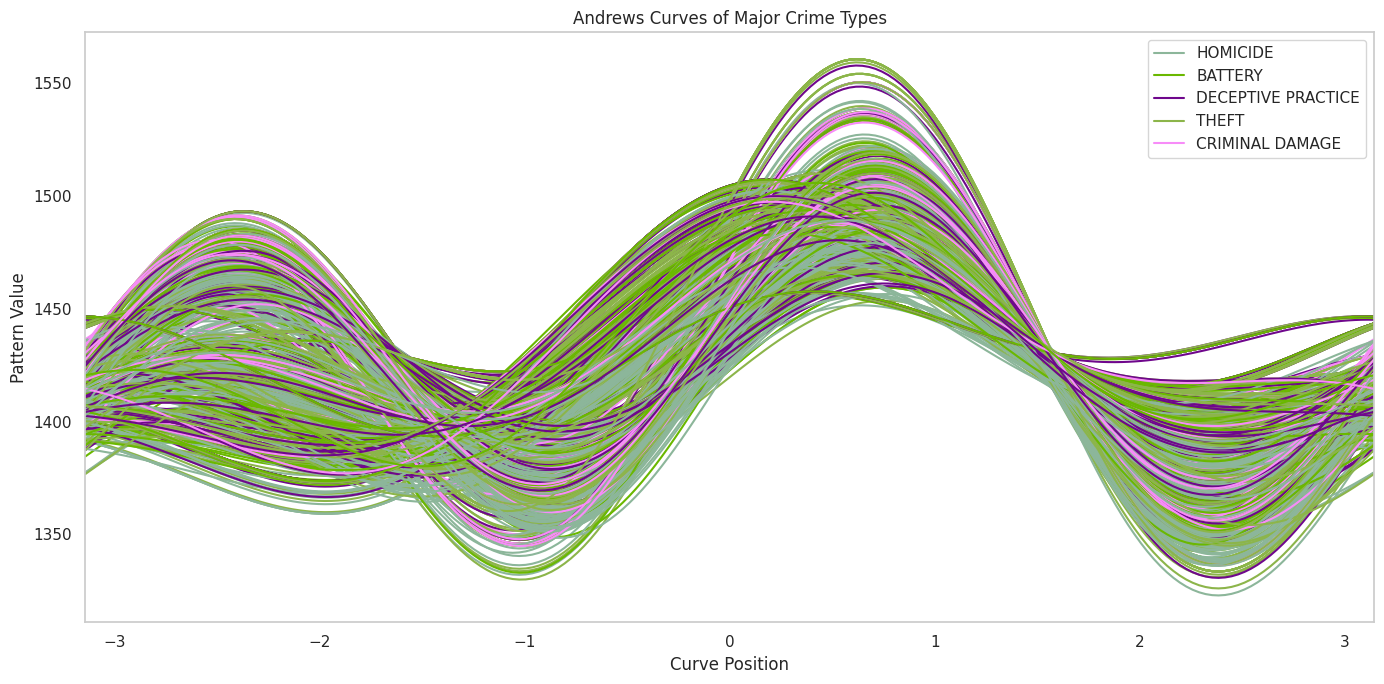

In [47]:


from pandas.plotting import andrews_curves

# Select the required columns
andrews_df = df[
    ['Primary Type', 'Year', 'District', 'Ward', 'Community Area']
].copy()

# Convert numerical columns safely
numeric_columns = [
    'Year',
    'District',
    'Ward',
    'Community Area'
]

for column in numeric_columns:
    andrews_df[column] = pd.to_numeric(
        andrews_df[column],
        errors='coerce'
    )

# Remove incomplete records
andrews_df = andrews_df.dropna()

# Select the 5 most common crime types
top_crimes = (
    andrews_df['Primary Type']
    .value_counts()
    .head(5)
    .index
)

andrews_df = andrews_df[
    andrews_df['Primary Type'].isin(top_crimes)
]

# Sample records for a readable plot
andrews_df = andrews_df.sample(
    min(1500, len(andrews_df)),
    random_state=42
)

# Create Andrews Curves
plt.figure(figsize=(14, 7))

andrews_curves(
    andrews_df,
    'Primary Type'
)

plt.title('Andrews Curves of Major Crime Types')
plt.xlabel('Curve Position')
plt.ylabel('Pattern Value')

plt.tight_layout()
plt.show()

Graph 24: Radar Chart

 Crime Distribution Across Days of the Week

Radar Chart – Weekly Crime Distribution:
The radar chart compares the number of reported crime incidents across the seven days of the week. Each axis represents a day, while the distance from the center represents the number of incidents. This helps identify which days have relatively higher or lower crime activity.

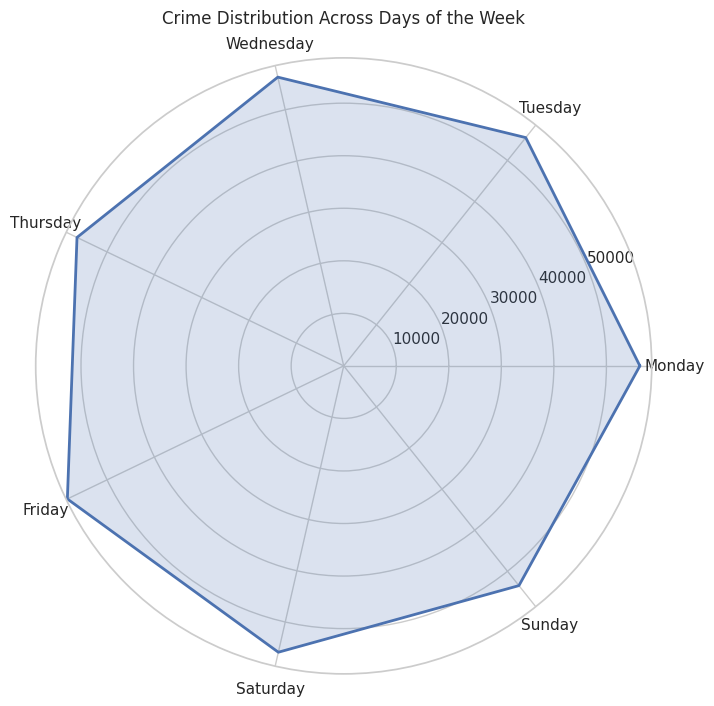

In [50]:
# Graph 24: Radar Chart
# Crime Distribution Across Days of the Week

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

# Count crimes for each day
weekly_crimes = (
    df['Day_of_Week']
    .value_counts()
    .reindex(day_order, fill_value=0)
)

# Values for the radar chart
values = weekly_crimes.values.tolist()

# Close the radar shape
values += [values[0]]

# Calculate angles
angles = np.linspace(
    0,
    2 * np.pi,
    len(day_order),
    endpoint=False
).tolist()

angles += [angles[0]]

# Create radar chart
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(
    111,
    polar=True
)

ax.plot(
    angles,
    values,
    linewidth=2
)

ax.fill(
    angles,
    values,
    alpha=0.2
)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(day_order)

ax.set_title(
    'Crime Distribution Across Days of the Week',
    pad=25
)

plt.show()

Graph 25: Dendrogram

Similarity of Crime Types Across Districts

The dendrogram uses hierarchical clustering to group major crime types according to their distribution across police districts. Crime types that are connected at smaller distances have more similar district-level patterns, while larger distances indicate greater differences.

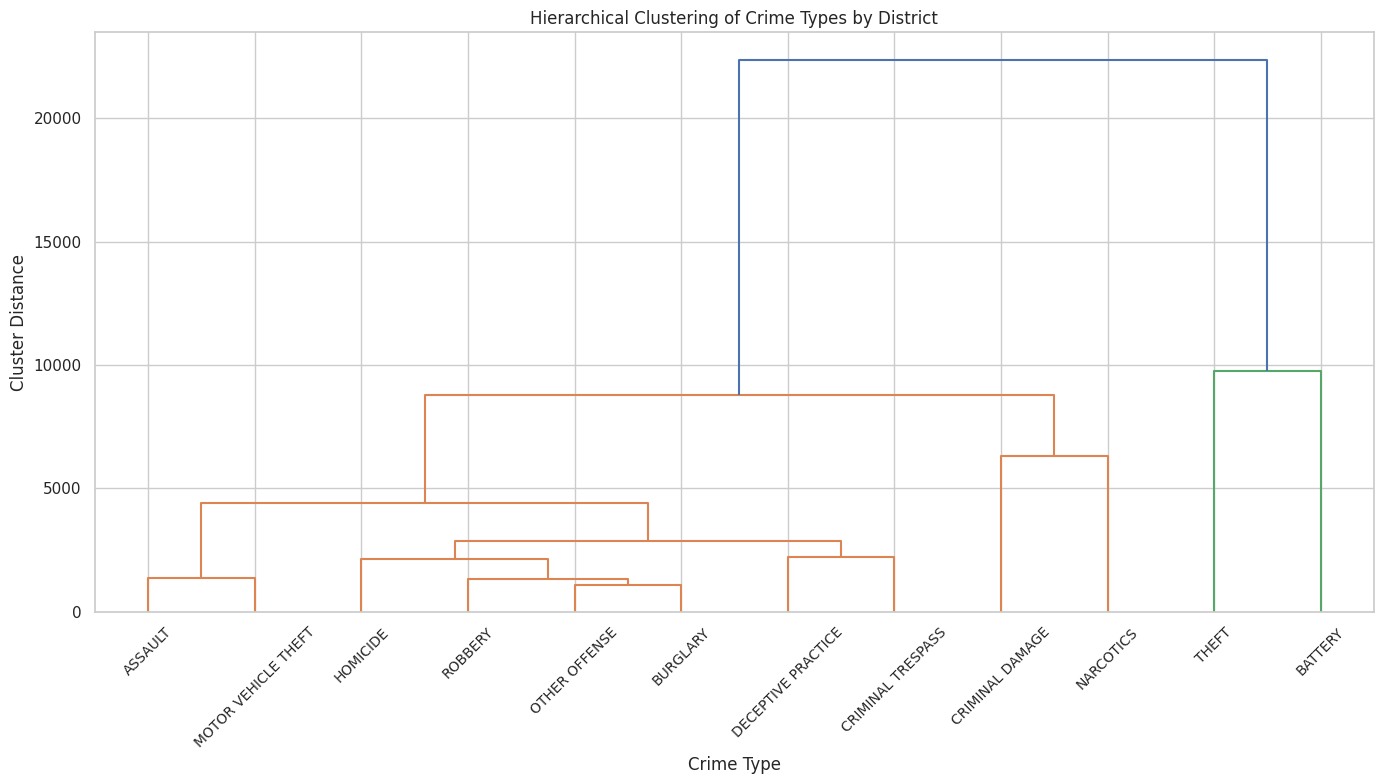

In [52]:


from scipy.cluster.hierarchy import linkage, dendrogram

# Select the 12 most common crime types
top_crimes = (
    df['Primary Type']
    .dropna()
    .value_counts()
    .head(12)
    .index
)

# Create a Crime Type × District frequency table
crime_district = pd.crosstab(
    df['Primary Type'],
    df['District']
)

# Keep only the selected crime types
crime_district = crime_district.loc[top_crimes]

# Convert values to numeric
crime_district = crime_district.apply(
    pd.to_numeric,
    errors='coerce'
).fillna(0)

# Perform hierarchical clustering
linked = linkage(
    crime_district.values,
    method='ward'
)

# Plot dendrogram
plt.figure(figsize=(14, 8))

dendrogram(
    linked,
    labels=crime_district.index.tolist(),
    leaf_rotation=45,
    leaf_font_size=10
)

plt.title(
    'Hierarchical Clustering of Crime Types by District'
)

plt.xlabel('Crime Type')
plt.ylabel('Cluster Distance')

plt.tight_layout()
plt.show()

Graph 26: PCA Visualization

Reducing multiple crime-related variables into two dimensions

Principal Component Analysis reduces multiple numerical variables—year, district, ward, and community area—into two principal components. The scatter plot allows overall similarities and differences among crime records to be observed in a two-dimensional space.

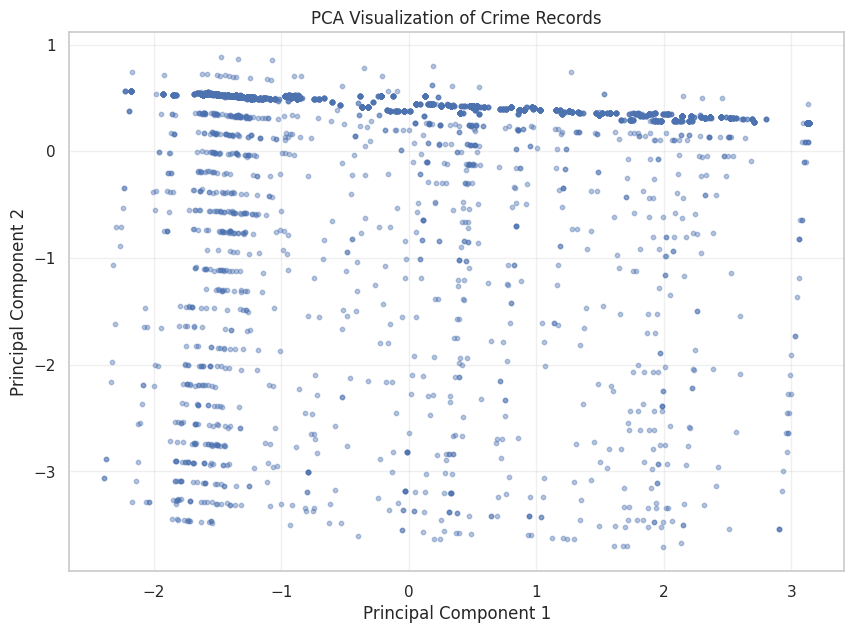

Explained variance by PC1: 54.11 %
Explained variance by PC2: 24.93 %


In [53]:


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select numerical variables
pca_df = df[
    ['Year', 'District', 'Ward', 'Community Area']
].copy()

# Convert values to numeric
for column in pca_df.columns:
    pca_df[column] = pd.to_numeric(
        pca_df[column],
        errors='coerce'
    )

# Remove rows with missing values
pca_df = pca_df.dropna()

# Use a sample because the dataset is very large
pca_df = pca_df.sample(
    min(5000, len(pca_df)),
    random_state=42
)

# Standardize the variables
scaler = StandardScaler()

scaled_data = scaler.fit_transform(pca_df)

# Apply PCA
pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_data)

# Create the PCA plot
plt.figure(figsize=(10, 7))

plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    s=10,
    alpha=0.4
)

plt.title('PCA Visualization of Crime Records')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.grid(True, alpha=0.3)

plt.show()

# Display explained variance
print(
    'Explained variance by PC1:',
    round(pca.explained_variance_ratio_[0] * 100, 2),
    '%'
)

print(
    'Explained variance by PC2:',
    round(pca.explained_variance_ratio_[1] * 100, 2),
    '%'
)

 Graph 27: Network Graph

Relationship Between Crime Types and Locations

The network graph represents relationships between major crime types and the locations where they occur. Crime types and locations are represented as nodes, while connections between them indicate that a particular crime has been reported at that location. Stronger connections represent more frequent crime-location combinations.

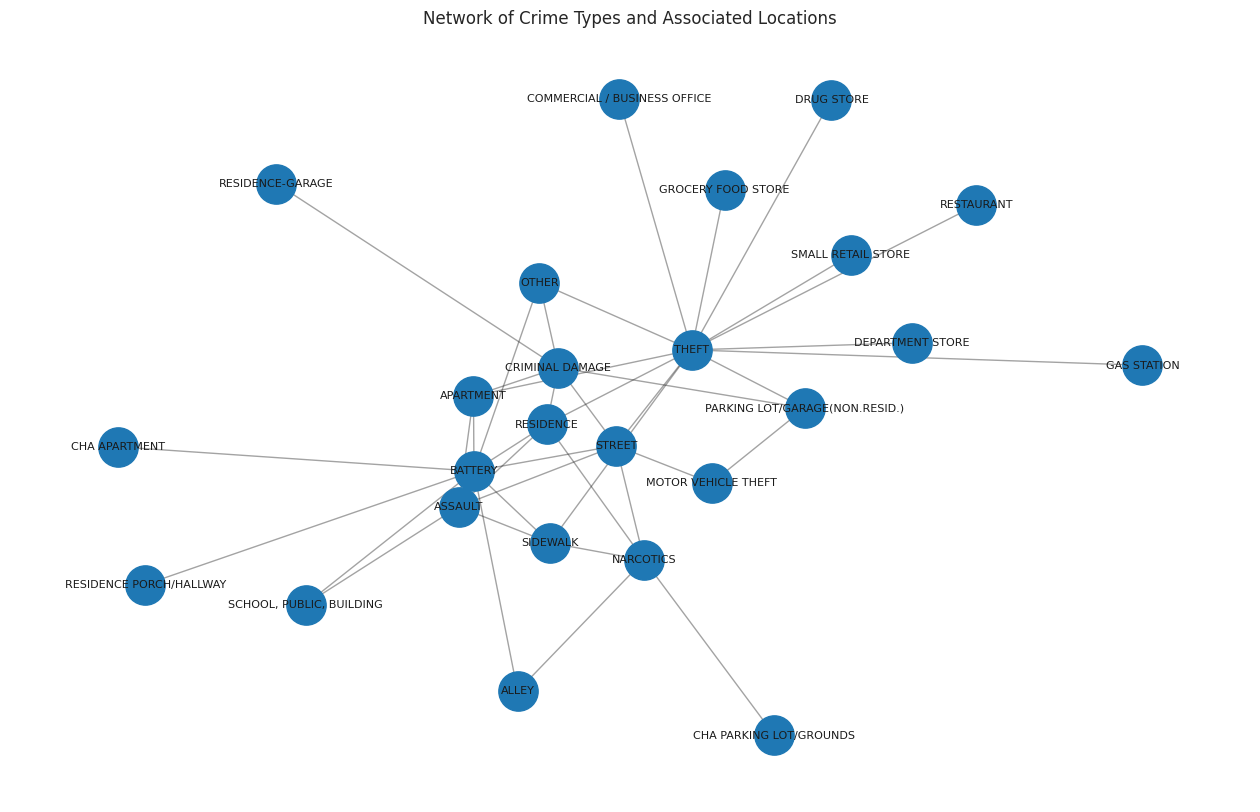

In [54]:


import networkx as nx

# Select the required columns
network_df = df[
    ['Primary Type', 'Location Description']
].dropna()

# Find the 6 most common crime types
top_crimes = (
    network_df['Primary Type']
    .value_counts()
    .head(6)
    .index
)

# Keep only those crime types
network_df = network_df[
    network_df['Primary Type'].isin(top_crimes)
]

# Count Crime Type - Location combinations
connections = (
    network_df
    .groupby(
        ['Primary Type', 'Location Description']
    )
    .size()
    .reset_index(name='Count')
)

# Keep the strongest 40 connections
connections = connections.nlargest(
    40,
    'Count'
)

# Create the network
G = nx.Graph()

for _, row in connections.iterrows():

    crime = row['Primary Type']
    location = row['Location Description']

    G.add_edge(
        crime,
        location,
        weight=int(row['Count'])
    )

# Create node positions
plt.figure(figsize=(16, 10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.8
)

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=800
)

# Draw connections
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.4
)

# Draw labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

plt.title(
    'Network of Crime Types and Associated Locations'
)

plt.axis('off')

plt.show()

 Graph 28: 3D Scatter Plot

 Crime Distribution Across Location and Year

 The 3D scatter plot represents crime incidents using three dimensions: longitude, latitude, and year. This visualization helps examine how crime records are distributed geographically while also showing their variation across different years.

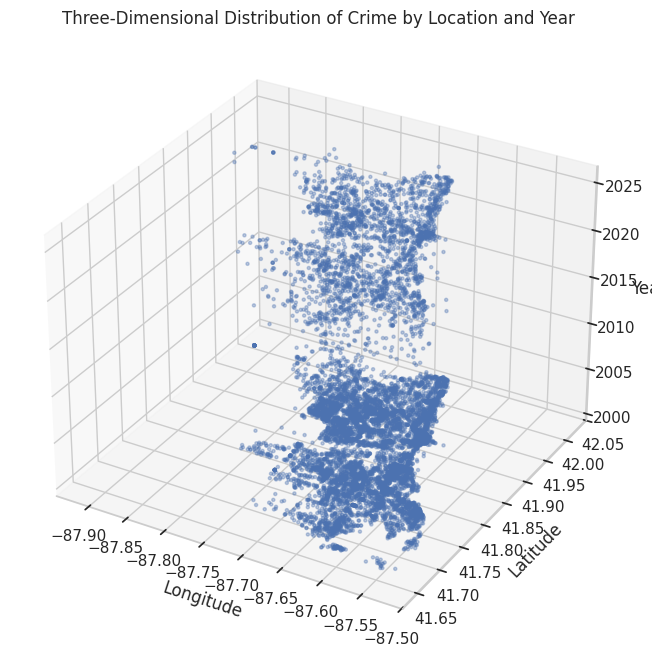

In [55]:


# Select required columns
three_d_df = df[
    ['Longitude', 'Latitude', 'Year']
].copy()

# Convert columns to numeric
for column in ['Longitude', 'Latitude', 'Year']:
    three_d_df[column] = pd.to_numeric(
        three_d_df[column],
        errors='coerce'
    )

# Remove missing values
three_d_df = three_d_df.dropna()

# Keep valid Chicago geographic coordinates
three_d_df = three_d_df[
    three_d_df['Longitude'].between(-88, -87) &
    three_d_df['Latitude'].between(41, 43)
]

# Sample records for better performance
three_d_df = three_d_df.sample(
    min(10000, len(three_d_df)),
    random_state=42
)

# Create 3D figure
fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

# Plot the data
ax.scatter(
    three_d_df['Longitude'],
    three_d_df['Latitude'],
    three_d_df['Year'],
    s=5,
    alpha=0.35
)

# Labels
ax.set_title(
    'Three-Dimensional Distribution of Crime by Location and Year'
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Year')

plt.show()

Graph 29: Word Cloud

Most Frequent Words in Crime Descriptions

The word cloud provides a visual representation of frequently occurring terms in the crime descriptions. Words appearing more frequently are displayed in larger sizes, allowing common crime-related terms and descriptions to be identified quickly.

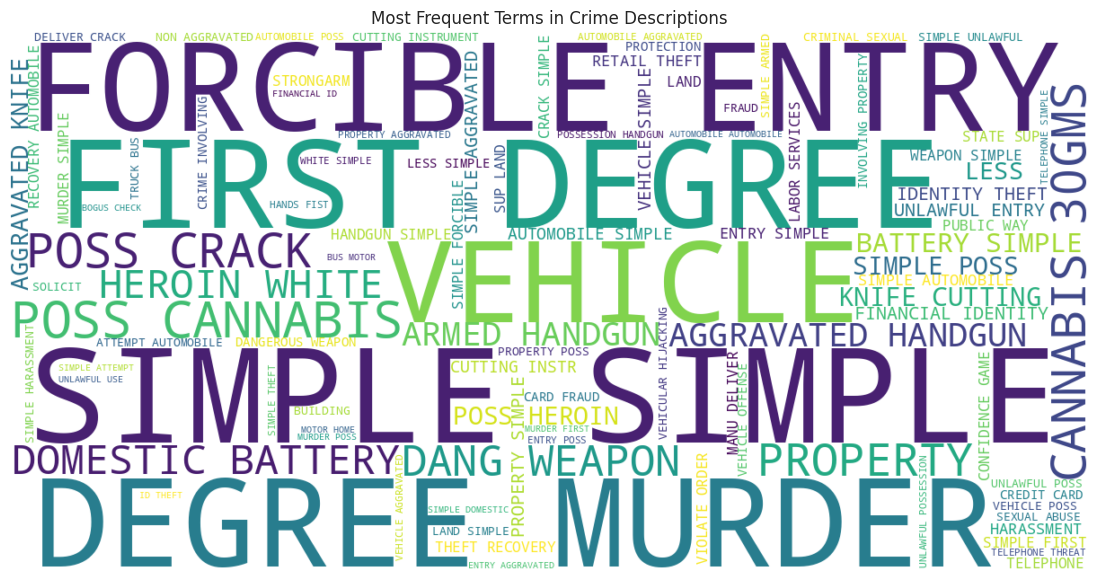

In [56]:

!pip install -q wordcloud

from wordcloud import WordCloud

# Collect crime descriptions
text = (
    df['Description']
    .dropna()
    .astype(str)
    .str.upper()
    .str.cat(sep=' ')
)

# Create the word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100,
    random_state=42
).generate(text)

# Display the word cloud
plt.figure(figsize=(14, 7))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.title(
    'Most Frequent Terms in Crime Descriptions'
)

plt.show()

Graph 30: Waterfall Chart

Cumulative Contribution of the Top 10 Crime Types

The waterfall chart illustrates how the ten most frequently reported crime types progressively contribute to the cumulative number of crime incidents. Each segment adds the incidents from one crime category to the previous cumulative total, making it possible to observe how quickly the major crime categories build up the overall total.

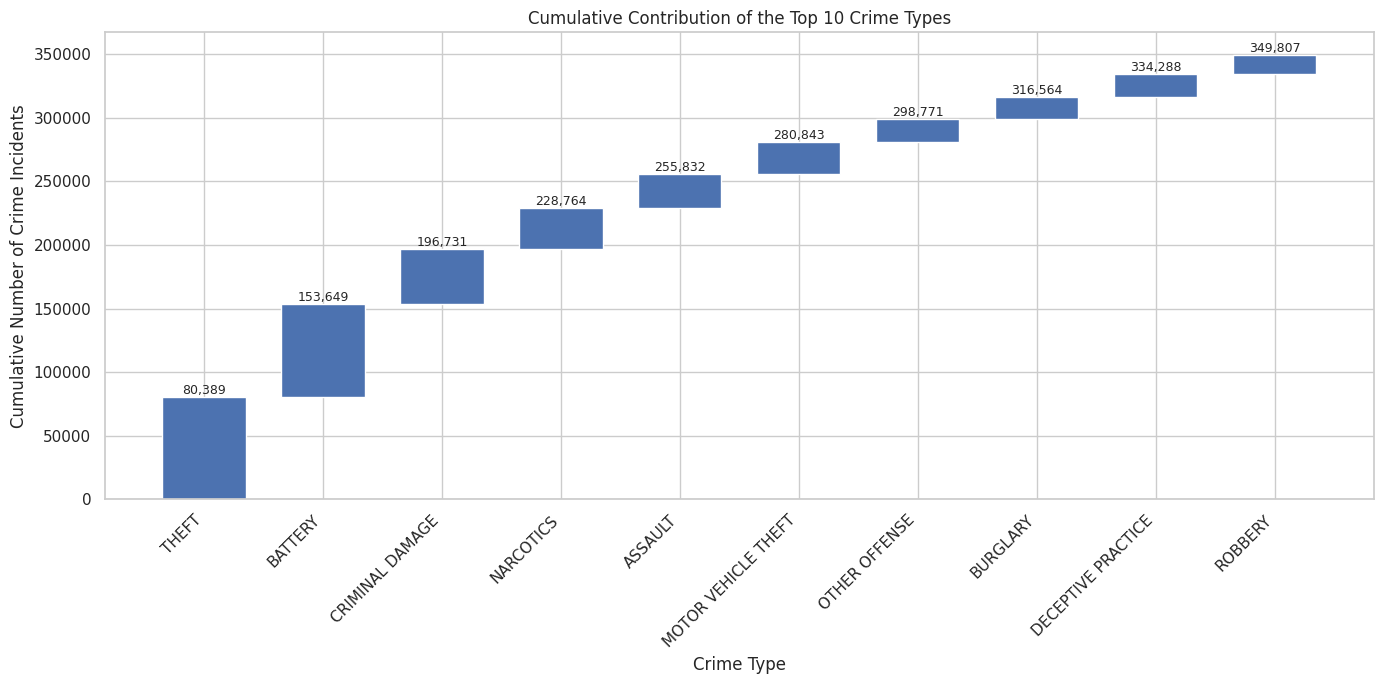

In [57]:

crime_counts = (
    df['Primary Type']
    .dropna()
    .value_counts()
    .head(10)
)

categories = crime_counts.index.tolist()
values = crime_counts.values.astype(float)

# Calculate cumulative totals
cumulative = np.cumsum(values)

# Starting position of each segment
starts = np.concatenate(
    ([0], cumulative[:-1])
)

# Create the waterfall chart
plt.figure(figsize=(14, 7))

plt.bar(
    range(len(values)),
    values,
    bottom=starts,
    width=0.7
)

# Add cumulative total labels
for i in range(len(values)):
    plt.text(
        i,
        cumulative[i],
        f'{int(cumulative[i]):,}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(
    range(len(values)),
    categories,
    rotation=45,
    ha='right'
)

plt.title(
    'Cumulative Contribution of the Top 10 Crime Types'
)

plt.xlabel('Crime Type')
plt.ylabel('Cumulative Number of Crime Incidents')

plt.tight_layout()

plt.show()